# Heart Sound Classification - Retraining with ESP32 Data

**Dataset:**
- 5 classes: AS, MR, MS, MVP, N
- Train: 2595 files (N=687, others=477 each)
- Test: 235 files (N=71, others=41 each)
- Includes ESP32-recorded Normal samples with pitch-shift augmentation

## Step 1: Setup and Mount Drive

In [7]:
!pip install tf_keras -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import pandas as pd
import librosa
import librosa.feature
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tf_keras as keras
from tf_keras.models import Sequential
from tf_keras.layers import Conv1D, Flatten, Dense, Dropout
from tf_keras.callbacks import EarlyStopping
from tf_keras.utils import to_categorical
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print(f"TensorFlow: {tf.__version__}")
print("Using tf_keras (Keras 2) for model building")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.19.0
Using tf_keras (Keras 2) for model building


## Step 2: Configuration

**IMPORTANT:** Upload the updated `DeepSignal` folder to your Google Drive and update the path below.

In [8]:
# ============================================================
# UPDATE THIS PATH to match your Google Drive location
# ============================================================
DRIVE_BASE = '/content/drive/MyDrive/NPU Project/DeepSignal'
# ============================================================

train_data_dir = os.path.join(DRIVE_BASE, 'TrainData')
train_labels_file = os.path.join(DRIVE_BASE, 'TrainLabels.xlsx')
test_data_dir = os.path.join(DRIVE_BASE, 'TestData')
test_labels_file = os.path.join(DRIVE_BASE, 'TestLabel.xlsx')

print(f'Train data dir: {train_data_dir}')
print(f'Test data dir: {test_data_dir}')
print(f'Train dir exists: {os.path.exists(train_data_dir)}')
print(f'Test dir exists: {os.path.exists(test_data_dir)}')

Train data dir: /content/drive/MyDrive/NPU Project/DeepSignal/TrainData
Test data dir: /content/drive/MyDrive/NPU Project/DeepSignal/TestData
Train dir exists: True
Test dir exists: True


## Step 3: Load Data

In [9]:
def specificity(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    fp = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
    tn = conf_matrix.sum() - (conf_matrix.sum(axis=1) + fp)
    spec = tn / (tn + fp)
    return np.mean(spec)

def load_data(data_dir, labels_file):
    labels_df = pd.read_excel(labels_file)
    data = []
    labels = []
    skipped = 0

    for file_name in os.listdir(data_dir):
        if file_name.endswith('.wav'):
            matching_rows = labels_df.loc[labels_df['Name'] == file_name]
            if len(matching_rows) > 0:
                file_path = os.path.join(data_dir, file_name)
                signal, sr = librosa.load(file_path, sr=None, duration=3.0)
                mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
                label = matching_rows['Label'].values[0]
                data.append(mfccs)
                labels.append(label)
            else:
                skipped += 1

    print(f'  Loaded {len(data)} files, skipped {skipped} (no label match)')
    return data, labels

print('Loading training data...')
train_data, train_labels = load_data(train_data_dir, train_labels_file)

print('Loading test data...')
test_data, test_labels = load_data(test_data_dir, test_labels_file)

Loading training data...
  Loaded 2595 files, skipped 25 (no label match)
Loading test data...
  Loaded 235 files, skipped 0 (no label match)


In [12]:
# Convert MFCCs to numpy arrays
train_data_mfccs = np.array(train_data)
test_data_mfccs = np.array(test_data)

# Reshape for Conv1D: add channel dimension
train_data_mfccs = np.expand_dims(train_data_mfccs, axis=3)
test_data_mfccs = np.expand_dims(test_data_mfccs, axis=3)

print(f'Train MFCCs shape: {train_data_mfccs.shape}')
print(f'Test MFCCs shape: {test_data_mfccs.shape}')

# Encode labels
label_encoder = LabelEncoder()
encoded_train_labels = label_encoder.fit_transform(train_labels)
encoded_test_labels = label_encoder.transform(test_labels)

num_classes = len(label_encoder.classes_)
class_names = list(label_encoder.classes_)

print(f'\nClasses ({num_classes}): {class_names}')
print(f'Label encoding: {dict(zip(class_names, label_encoder.transform(class_names)))}')

# One-hot encode
train_labels_cat = to_categorical(encoded_train_labels, num_classes=num_classes)
test_labels_cat = to_categorical(encoded_test_labels, num_classes=num_classes)

# Show class distribution
print(f'\nTrain class distribution:')
unique, counts = np.unique(encoded_train_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {class_names[u]}: {c}')

print(f'\nTest class distribution:')
unique, counts = np.unique(encoded_test_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {class_names[u]}: {c}')

Train MFCCs shape: (2595, 13, 47, 1)
Test MFCCs shape: (235, 13, 47, 1)

Classes (5): [np.str_('AS'), np.str_('MR'), np.str_('MS'), np.str_('MVP'), np.str_('N')]
Label encoding: {np.str_('AS'): np.int64(0), np.str_('MR'): np.int64(1), np.str_('MS'): np.int64(2), np.str_('MVP'): np.int64(3), np.str_('N'): np.int64(4)}

Train class distribution:
  AS: 477
  MR: 477
  MS: 477
  MVP: 477
  N: 687

Test class distribution:
  AS: 41
  MR: 41
  MS: 41
  MVP: 41
  N: 71


## Step 4: Compute Class Weights (handle imbalance)

Since N class has 687 samples vs 477 for others (1.44x ratio), we use class weights to prevent bias.

In [13]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(encoded_train_labels),
    y=encoded_train_labels
)
class_weights = dict(enumerate(class_weights_array))

print('Class weights (to handle imbalance):')
for idx, weight in class_weights.items():
    print(f'  {class_names[idx]}: {weight:.4f}')

Class weights (to handle imbalance):
  AS: 1.0881
  MR: 1.0881
  MS: 1.0881
  MVP: 1.0881
  N: 0.7555


## Step 5: 5-Fold Cross-Validation Training


FOLD 1/5
Epoch 1/1000
292/292 [==============================] - 8s 11ms/step - loss: 1.4484 - accuracy: 0.3550 - val_loss: 0.9232 - val_accuracy: 0.7154
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.0612 - accuracy: 0.5443 - val_loss: 0.6337 - val_accuracy: 0.8769
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.8151 - accuracy: 0.6822 - val_loss: 0.4003 - val_accuracy: 0.9346
Epoch 4/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6330 - accuracy: 0.7602 - val_loss: 0.3009 - val_accuracy: 0.9500
Epoch 5/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.5645 - accuracy: 0.7833 - val_loss: 0.2136 - val_accuracy: 0.9577
Epoch 6/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4973 - accuracy: 0.8086 - val_loss: 0.1726 - val_accuracy: 0.9731
Epoch 7/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4334 - accuracy: 0.8535 - val_loss: 0.1318 - va

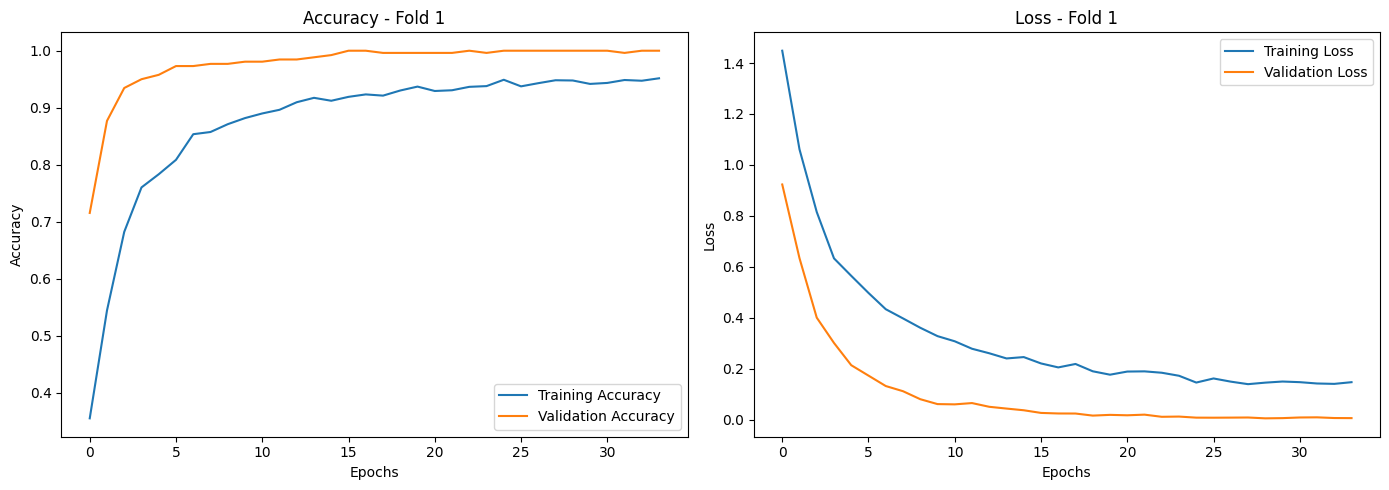

9/9 [==============================] - 0s 2ms/step


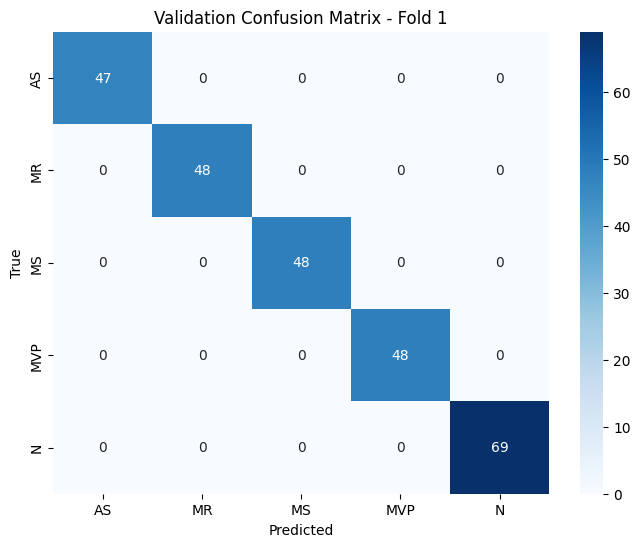

8/8 [==============================] - 0s 2ms/step


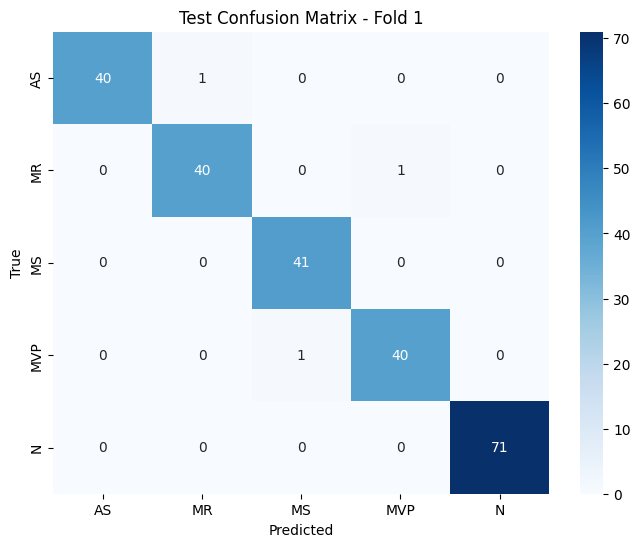


Fold 1 Results:
  Train Acc: 0.9516
  Val Acc:   1.0000
  Test Acc:  0.9872
  Sensitivity (macro): 0.9854
  Specificity (macro): 0.9969
  F1 Score (macro):    0.9854
  >>> New best model! (Fold 1, Test Acc: 0.9872)
  Saved model_fold_1.h5

FOLD 2/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 8s 8ms/step - loss: 1.5624 - accuracy: 0.2989 - val_loss: 1.2995 - val_accuracy: 0.4615
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.2532 - accuracy: 0.4660 - val_loss: 0.9282 - val_accuracy: 0.6077
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.0084 - accuracy: 0.5803 - val_loss: 0.6496 - val_accuracy: 0.8808
Epoch 4/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.8766 - accuracy: 0.6493 - val_loss: 0.5219 - val_accuracy: 0.9038
Epoch 5/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.7655 - accuracy: 0.6887 - val_loss: 0.3996 - val_accuracy: 0.9538
Epoch 6/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6902 - accuracy: 0.7221 - val_loss: 0.3300 - val_accuracy: 0.9577
Epoch 7/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6583 - accuracy: 0.7448 - val_loss: 0.2804 - val_accuracy:

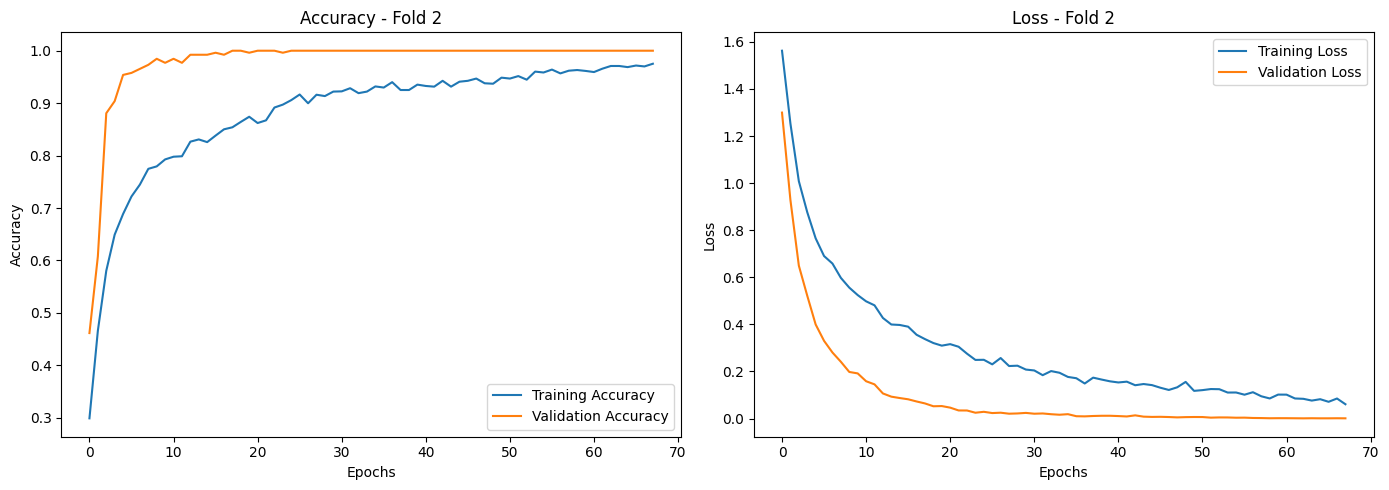

9/9 [==============================] - 0s 2ms/step


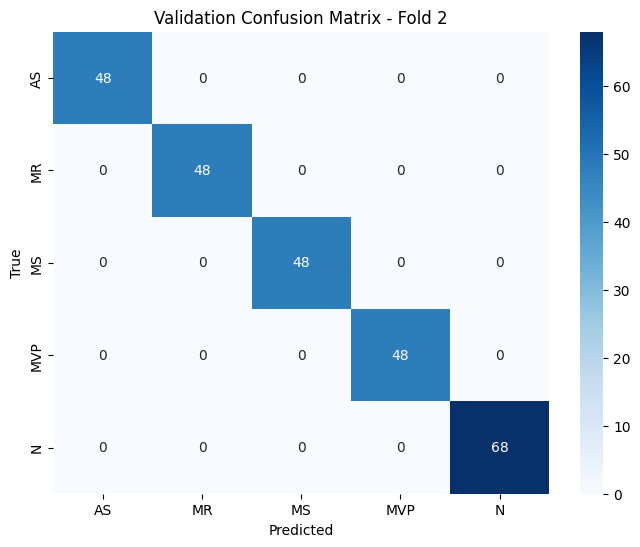

8/8 [==============================] - 0s 2ms/step


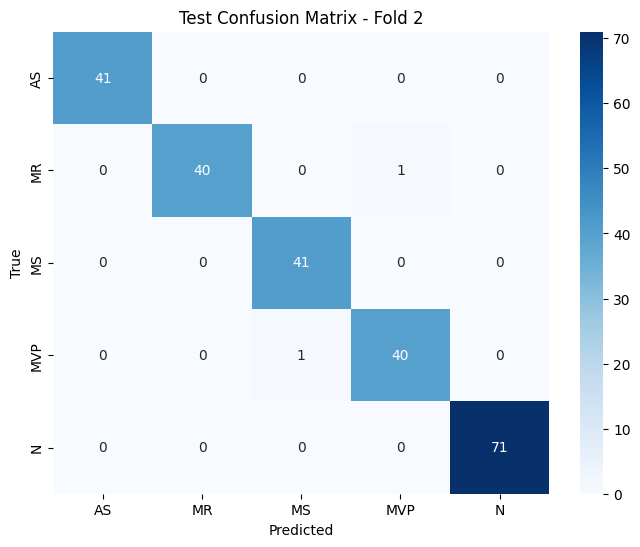


Fold 2 Results:
  Train Acc: 0.9752
  Val Acc:   1.0000
  Test Acc:  0.9915
  Sensitivity (macro): 0.9902
  Specificity (macro): 0.9979
  F1 Score (macro):    0.9902
  >>> New best model! (Fold 2, Test Acc: 0.9915)
  Saved model_fold_2.h5

FOLD 3/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 8s 9ms/step - loss: 1.5061 - accuracy: 0.3281 - val_loss: 1.1194 - val_accuracy: 0.7500
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.1570 - accuracy: 0.5585 - val_loss: 0.6766 - val_accuracy: 0.8731
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.8661 - accuracy: 0.6981 - val_loss: 0.4684 - val_accuracy: 0.9038
Epoch 4/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6614 - accuracy: 0.7790 - val_loss: 0.2929 - val_accuracy: 0.9500
Epoch 5/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.5729 - accuracy: 0.8090 - val_loss: 0.2711 - val_accuracy: 0.9538
Epoch 6/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.5278 - accuracy: 0.8218 - val_loss: 0.1807 - val_accuracy: 0.9808
Epoch 7/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4458 - accuracy: 0.8480 - val_loss: 0.1512 - val_accuracy:

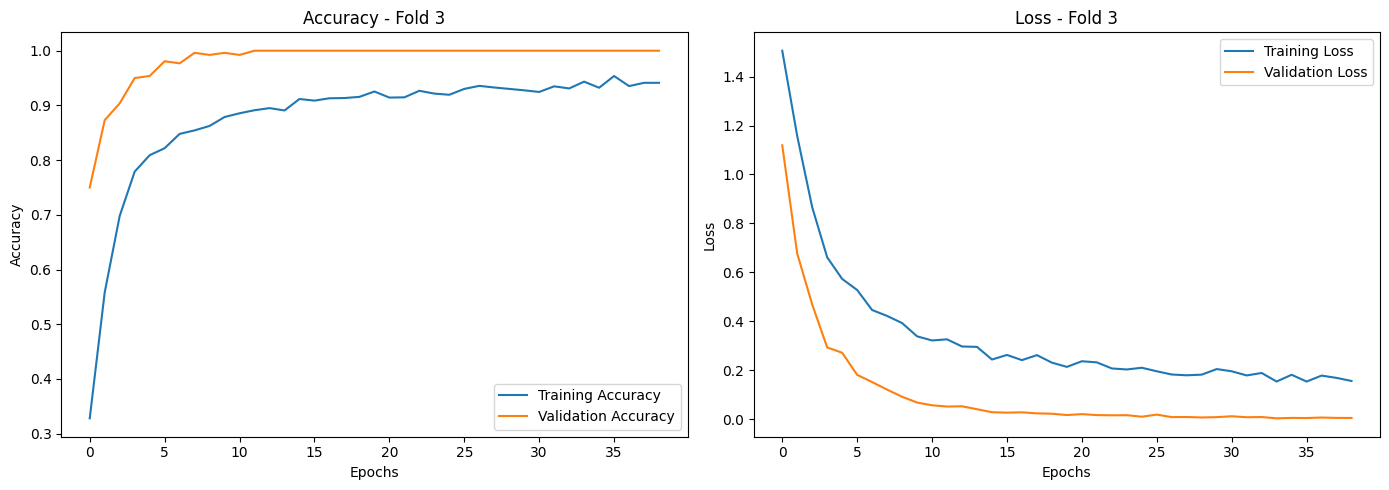

9/9 [==============================] - 0s 2ms/step


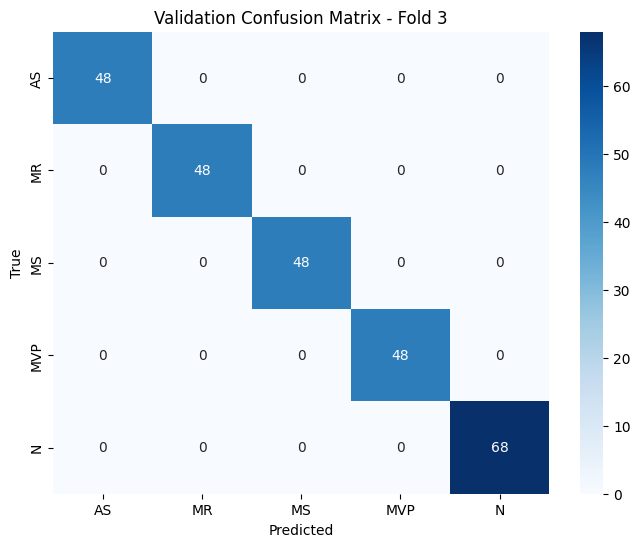

8/8 [==============================] - 0s 2ms/step


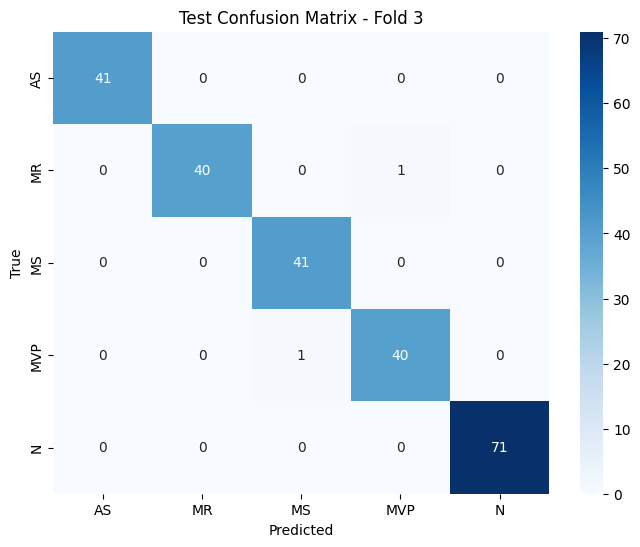


Fold 3 Results:
  Train Acc: 0.9413
  Val Acc:   1.0000
  Test Acc:  0.9915
  Sensitivity (macro): 0.9902
  Specificity (macro): 0.9979
  F1 Score (macro):    0.9902
  Saved model_fold_3.h5

FOLD 4/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 8s 9ms/step - loss: 1.4941 - accuracy: 0.3221 - val_loss: 1.1055 - val_accuracy: 0.7231
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.1005 - accuracy: 0.5503 - val_loss: 0.6540 - val_accuracy: 0.8192
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.8239 - accuracy: 0.6882 - val_loss: 0.3973 - val_accuracy: 0.9423
Epoch 4/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6402 - accuracy: 0.7666 - val_loss: 0.2563 - val_accuracy: 0.9500
Epoch 5/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.5335 - accuracy: 0.7970 - val_loss: 0.2118 - val_accuracy: 0.9577
Epoch 6/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4836 - accuracy: 0.8176 - val_loss: 0.1530 - val_accuracy: 0.9692
Epoch 7/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4267 - accuracy: 0.8428 - val_loss: 0.1225 - val_accuracy:

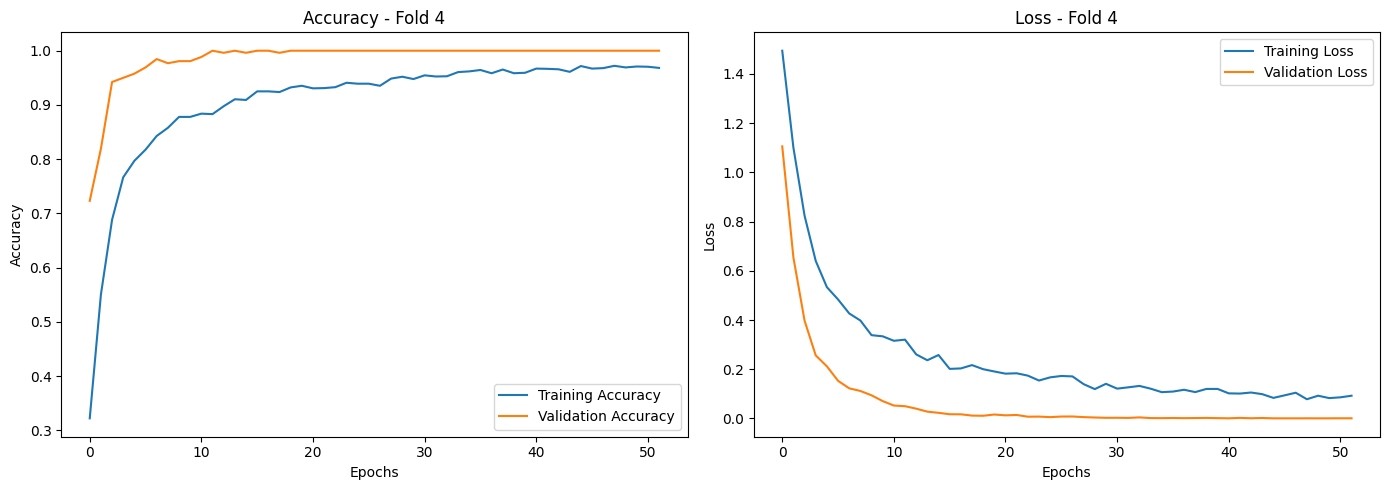

9/9 [==============================] - 0s 2ms/step


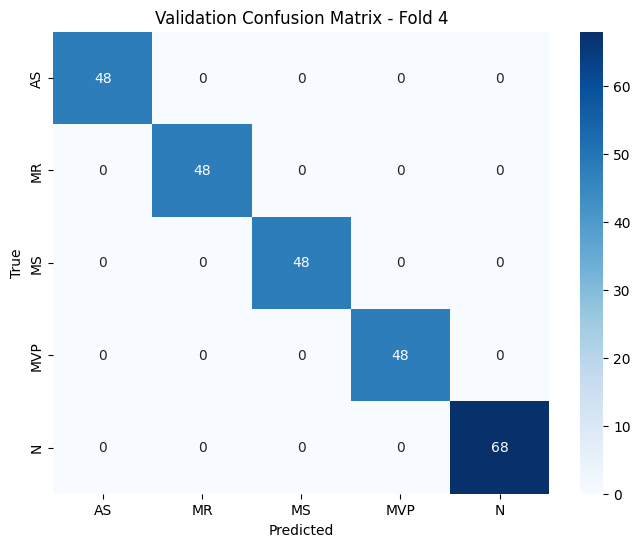

8/8 [==============================] - 0s 2ms/step


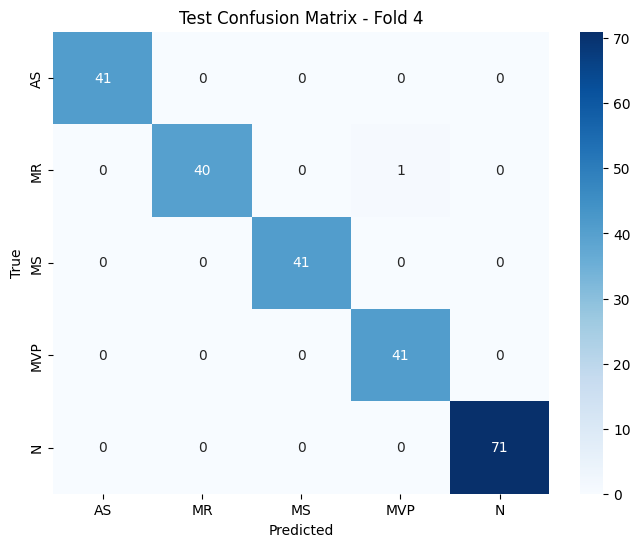


Fold 4 Results:
  Train Acc: 0.9683
  Val Acc:   1.0000
  Test Acc:  0.9957
  Sensitivity (macro): 0.9951
  Specificity (macro): 0.9990
  F1 Score (macro):    0.9951
  >>> New best model! (Fold 4, Test Acc: 0.9957)
  Saved model_fold_4.h5

FOLD 5/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 8s 8ms/step - loss: 1.4947 - accuracy: 0.3675 - val_loss: 1.1430 - val_accuracy: 0.6346
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.0564 - accuracy: 0.6077 - val_loss: 0.6379 - val_accuracy: 0.8885
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.7666 - accuracy: 0.7358 - val_loss: 0.3767 - val_accuracy: 0.9423
Epoch 4/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6196 - accuracy: 0.7850 - val_loss: 0.2644 - val_accuracy: 0.9462
Epoch 5/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.5658 - accuracy: 0.8051 - val_loss: 0.2330 - val_accuracy: 0.9577
Epoch 6/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4795 - accuracy: 0.8278 - val_loss: 0.1757 - val_accuracy: 0.9654
Epoch 7/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.4273 - accuracy: 0.8578 - val_loss: 0.1464 - val_accuracy:

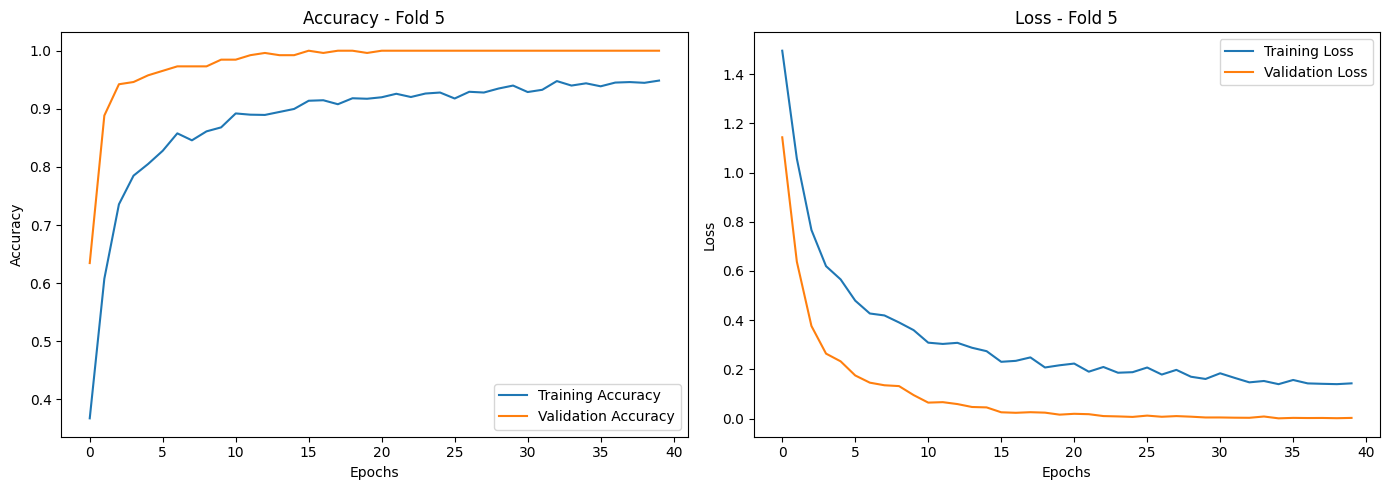

9/9 [==============================] - 0s 2ms/step


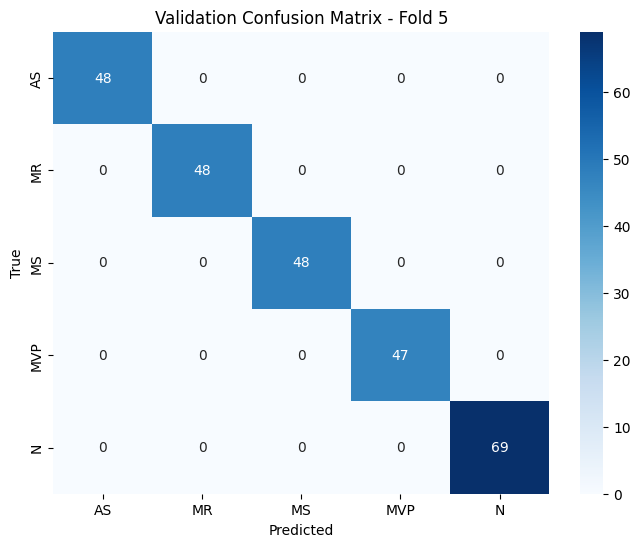

8/8 [==============================] - 0s 2ms/step


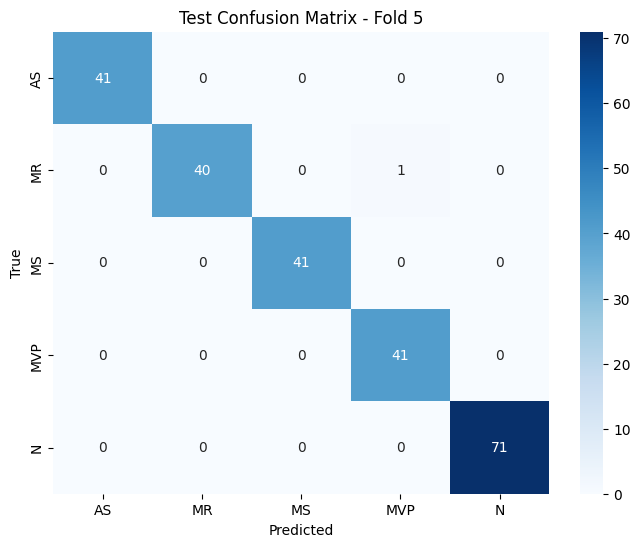


Fold 5 Results:
  Train Acc: 0.9486
  Val Acc:   1.0000
  Test Acc:  0.9957
  Sensitivity (macro): 0.9951
  Specificity (macro): 0.9990
  F1 Score (macro):    0.9951
  Saved model_fold_5.h5

FOLD 6/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 7s 8ms/step - loss: 1.4854 - accuracy: 0.3724 - val_loss: 1.2231 - val_accuracy: 0.5251
Epoch 2/1000
292/292 [==============================] - 2s 6ms/step - loss: 1.1198 - accuracy: 0.5783 - val_loss: 0.7245 - val_accuracy: 0.8147
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.8300 - accuracy: 0.6815 - val_loss: 0.4523 - val_accuracy: 0.8726
Epoch 4/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.6814 - accuracy: 0.7282 - val_loss: 0.3504 - val_accuracy: 0.9228
Epoch 5/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.6050 - accuracy: 0.7607 - val_loss: 0.2800 - val_accuracy: 0.9073
Epoch 6/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.5419 - accuracy: 0.7860 - val_loss: 0.2456 - val_accuracy: 0.9305
Epoch 7/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.5245 - accuracy: 0.7812 - val_loss: 0.2323 - val_accuracy:

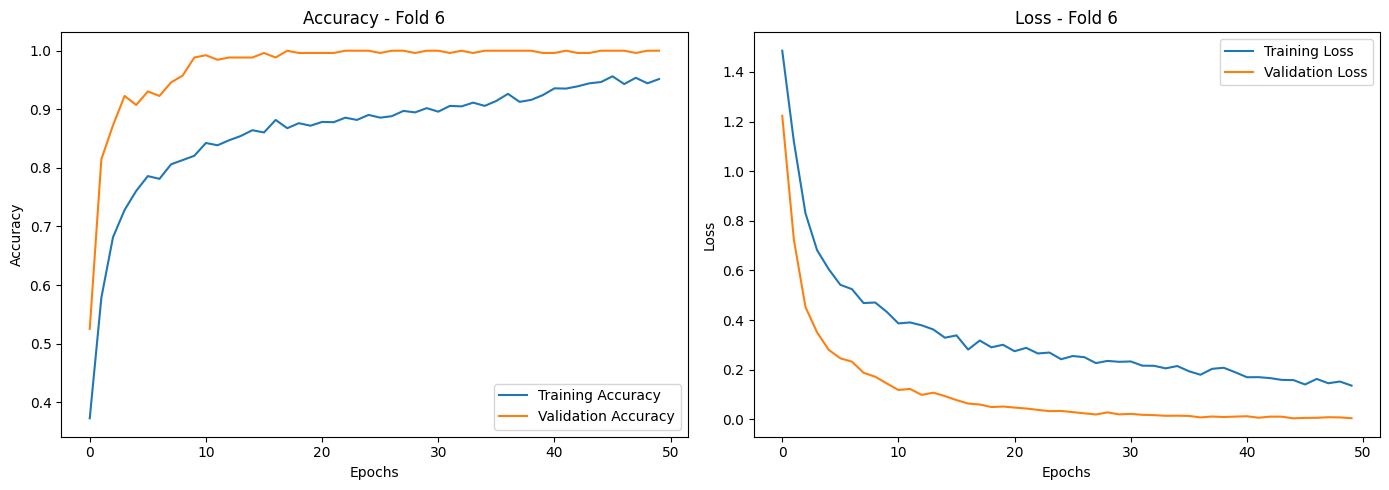

9/9 [==============================] - 0s 2ms/step


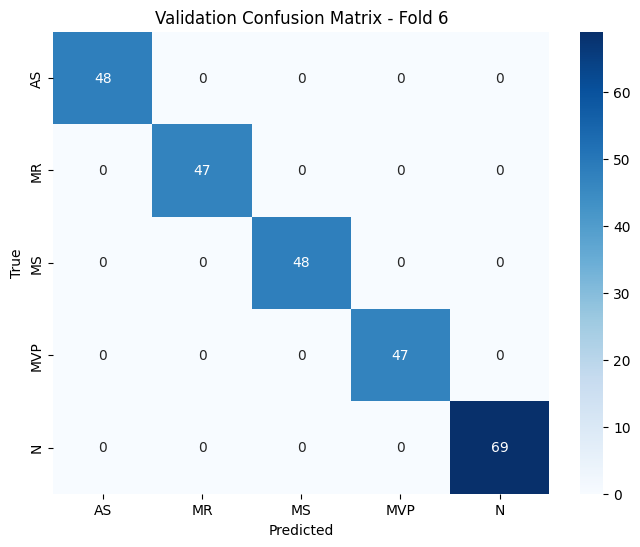

8/8 [==============================] - 0s 2ms/step


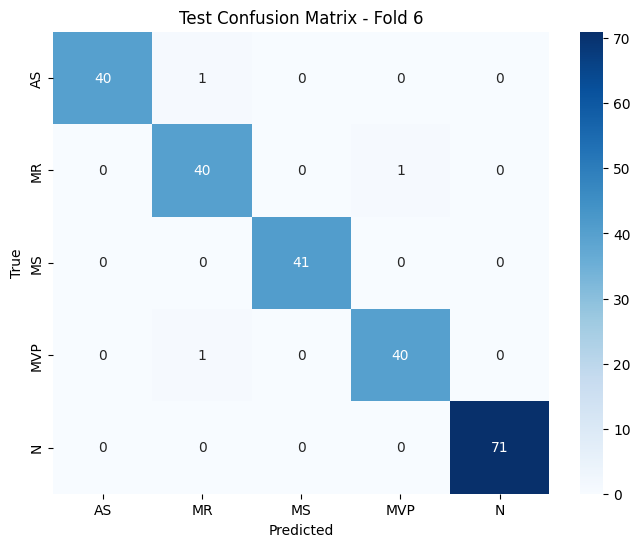


Fold 6 Results:
  Train Acc: 0.9516
  Val Acc:   1.0000
  Test Acc:  0.9872
  Sensitivity (macro): 0.9854
  Specificity (macro): 0.9969
  F1 Score (macro):    0.9854
  Saved model_fold_6.h5

FOLD 7/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 7s 8ms/step - loss: 1.4125 - accuracy: 0.3793 - val_loss: 0.9656 - val_accuracy: 0.7490
Epoch 2/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.9746 - accuracy: 0.6323 - val_loss: 0.5317 - val_accuracy: 0.8571
Epoch 3/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.6967 - accuracy: 0.7517 - val_loss: 0.3465 - val_accuracy: 0.8958
Epoch 4/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.5565 - accuracy: 0.8082 - val_loss: 0.2591 - val_accuracy: 0.9189
Epoch 5/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.5126 - accuracy: 0.8236 - val_loss: 0.2012 - val_accuracy: 0.9614
Epoch 6/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.4228 - accuracy: 0.8592 - val_loss: 0.1530 - val_accuracy: 0.9730
Epoch 7/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.3783 - accuracy: 0.8746 - val_loss: 0.1262 - val_accuracy:

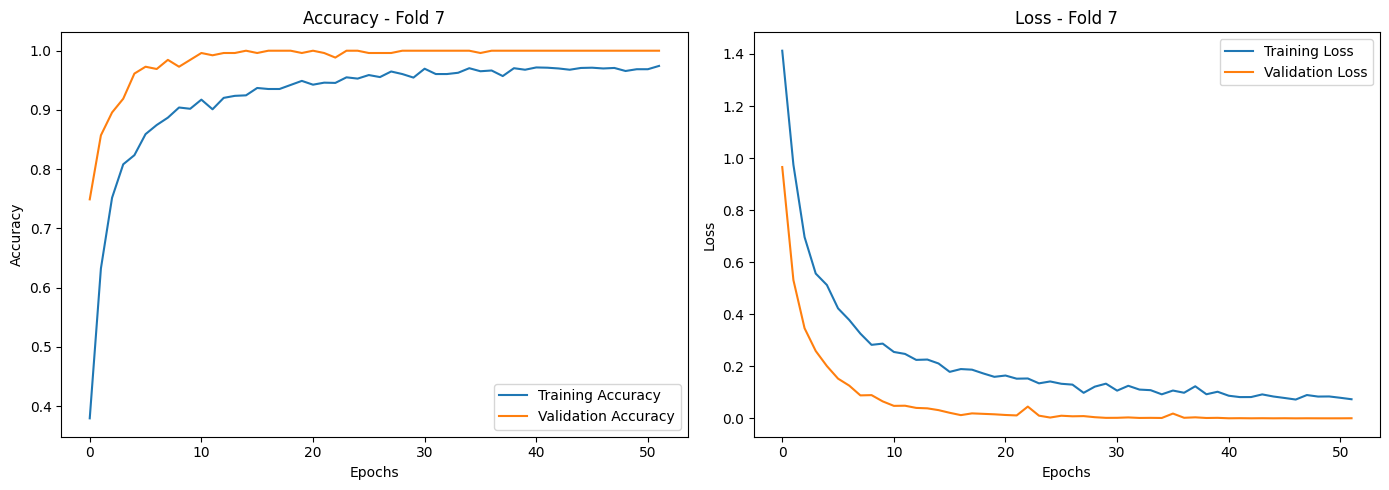

9/9 [==============================] - 0s 2ms/step


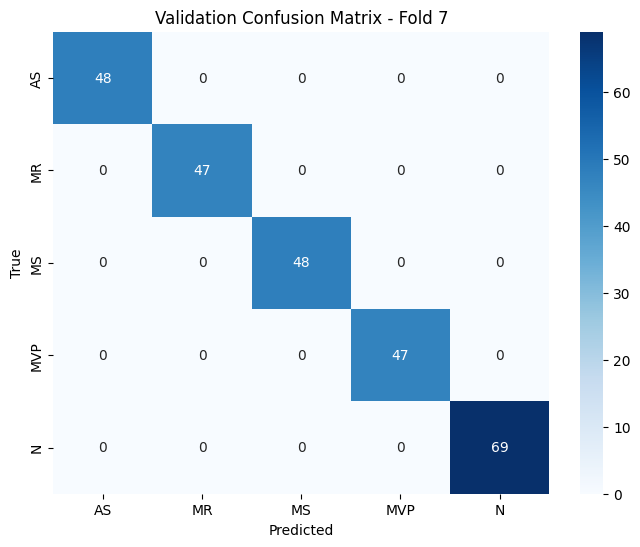

8/8 [==============================] - 0s 2ms/step


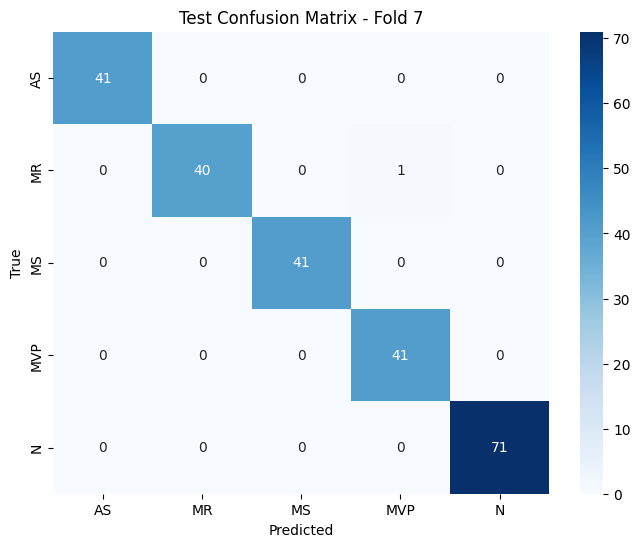


Fold 7 Results:
  Train Acc: 0.9743
  Val Acc:   1.0000
  Test Acc:  0.9957
  Sensitivity (macro): 0.9951
  Specificity (macro): 0.9990
  F1 Score (macro):    0.9951
  Saved model_fold_7.h5

FOLD 8/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 7s 8ms/step - loss: 1.5395 - accuracy: 0.3099 - val_loss: 1.2549 - val_accuracy: 0.5174
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.1940 - accuracy: 0.5137 - val_loss: 0.7504 - val_accuracy: 0.8842
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.9033 - accuracy: 0.6661 - val_loss: 0.4301 - val_accuracy: 0.9228
Epoch 4/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.7153 - accuracy: 0.7350 - val_loss: 0.2762 - val_accuracy: 0.9498
Epoch 5/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.6227 - accuracy: 0.7808 - val_loss: 0.2328 - val_accuracy: 0.9614
Epoch 6/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.5436 - accuracy: 0.8052 - val_loss: 0.1515 - val_accuracy: 0.9691
Epoch 7/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.4653 - accuracy: 0.8275 - val_loss: 0.1582 - val_accuracy:

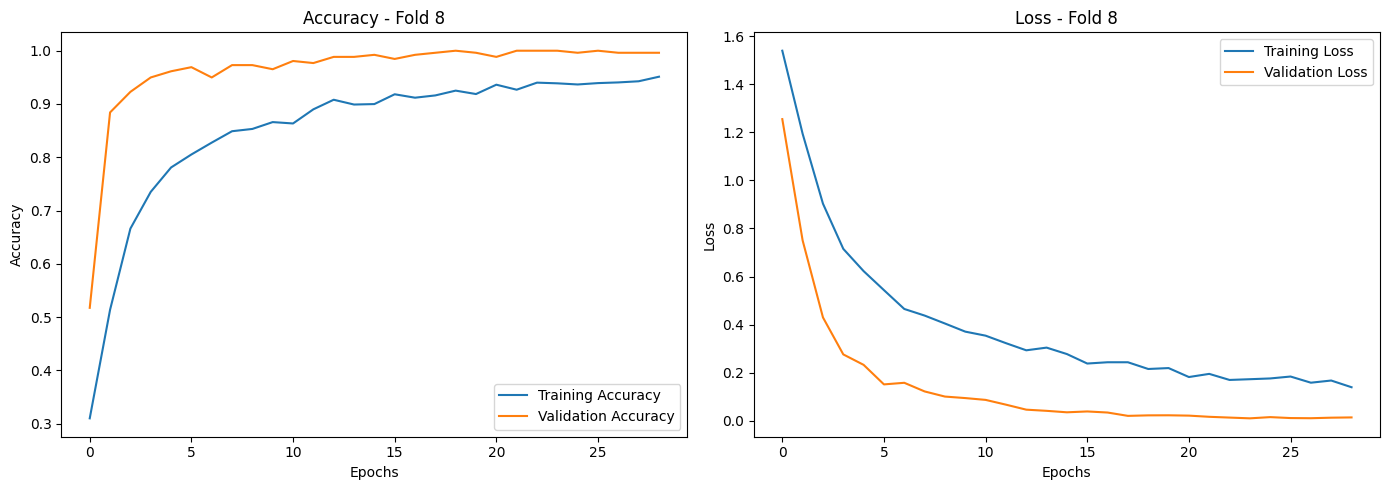

9/9 [==============================] - 0s 2ms/step


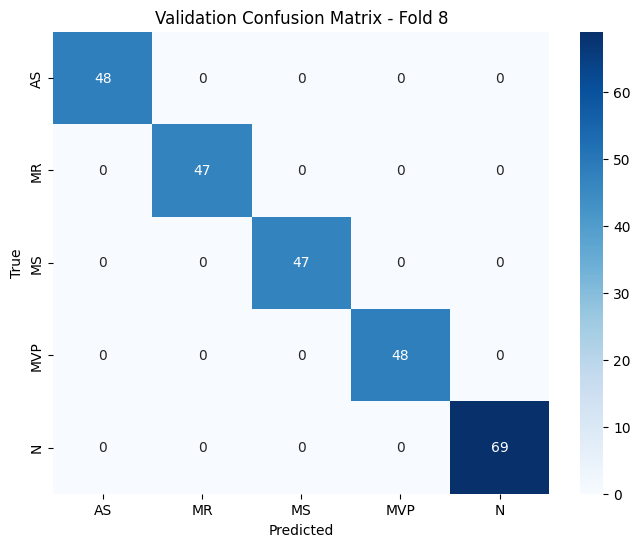

8/8 [==============================] - 0s 2ms/step


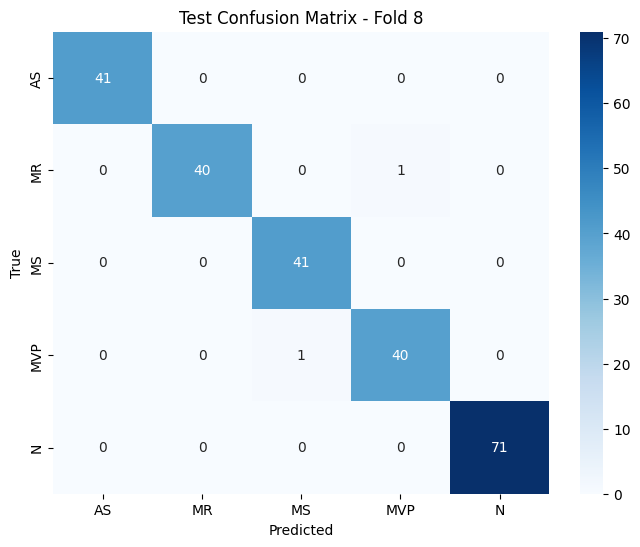


Fold 8 Results:
  Train Acc: 0.9512
  Val Acc:   0.9961
  Test Acc:  0.9915
  Sensitivity (macro): 0.9902
  Specificity (macro): 0.9979
  F1 Score (macro):    0.9902
  Saved model_fold_8.h5

FOLD 9/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 7s 8ms/step - loss: 1.4497 - accuracy: 0.3639 - val_loss: 1.0422 - val_accuracy: 0.6486
Epoch 2/1000
292/292 [==============================] - 2s 7ms/step - loss: 1.0381 - accuracy: 0.5706 - val_loss: 0.7227 - val_accuracy: 0.7375
Epoch 3/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.8144 - accuracy: 0.6854 - val_loss: 0.4739 - val_accuracy: 0.8880
Epoch 4/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.6782 - accuracy: 0.7440 - val_loss: 0.3904 - val_accuracy: 0.9151
Epoch 5/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.5819 - accuracy: 0.7808 - val_loss: 0.2900 - val_accuracy: 0.9189
Epoch 6/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.5417 - accuracy: 0.7984 - val_loss: 0.2404 - val_accuracy: 0.9614
Epoch 7/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.4629 - accuracy: 0.8305 - val_loss: 0.1935 - val_accuracy:

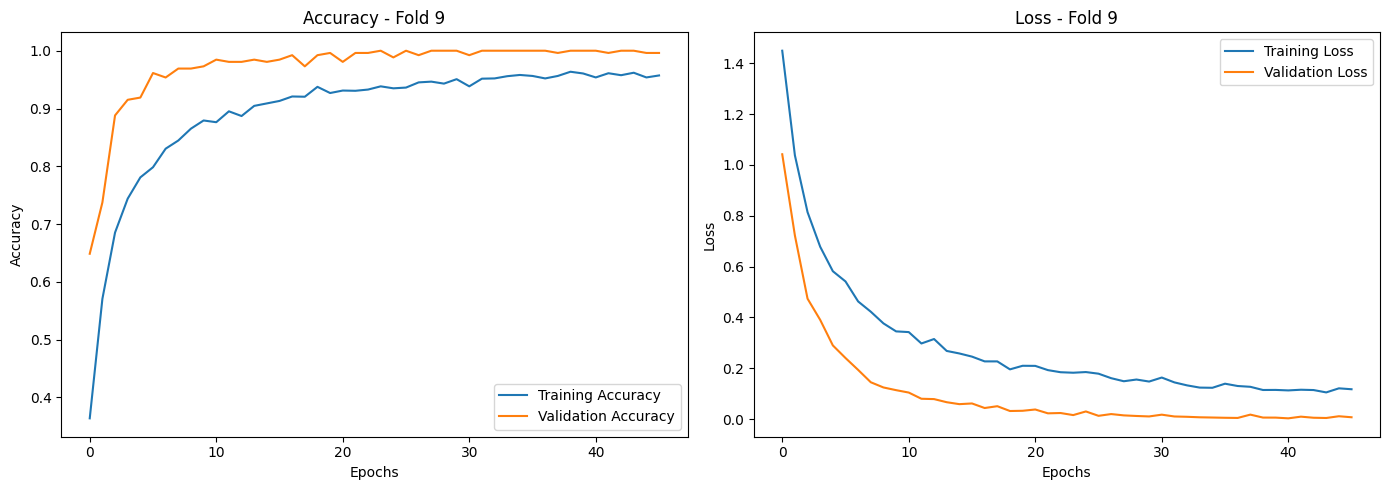

9/9 [==============================] - 0s 2ms/step


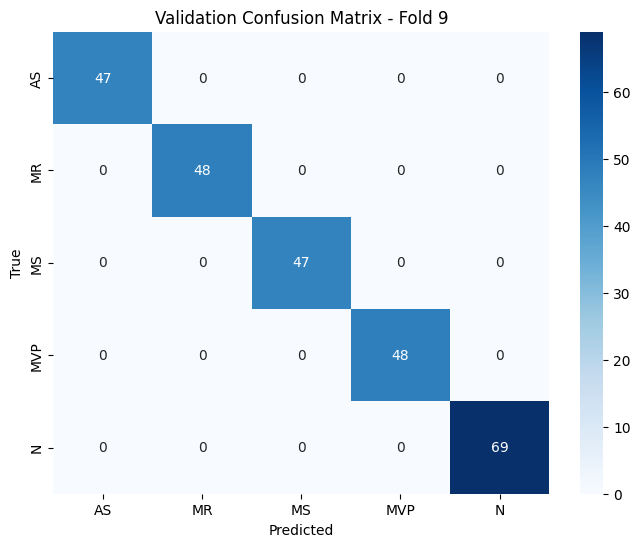

8/8 [==============================] - 0s 2ms/step


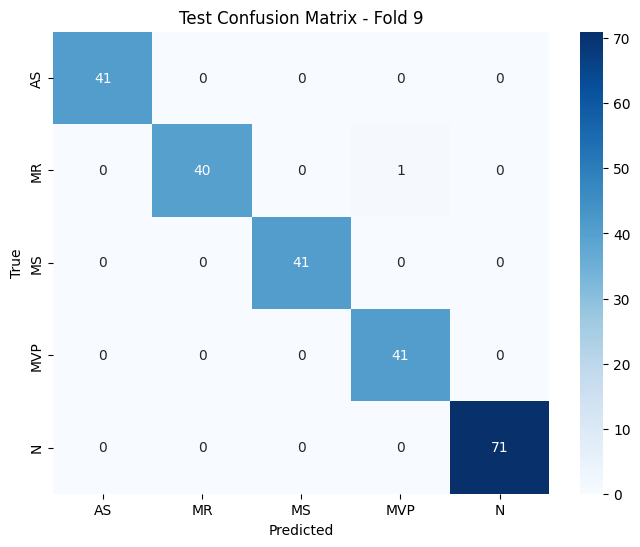


Fold 9 Results:
  Train Acc: 0.9572
  Val Acc:   0.9961
  Test Acc:  0.9957
  Sensitivity (macro): 0.9951
  Specificity (macro): 0.9990
  F1 Score (macro):    0.9951
  Saved model_fold_9.h5

FOLD 10/5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/1000
292/292 [==============================] - 7s 8ms/step - loss: 1.5697 - accuracy: 0.2971 - val_loss: 1.2471 - val_accuracy: 0.6023
Epoch 2/1000
292/292 [==============================] - 2s 6ms/step - loss: 1.2333 - accuracy: 0.4777 - val_loss: 0.8022 - val_accuracy: 0.7259
Epoch 3/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.9544 - accuracy: 0.6182 - val_loss: 0.5573 - val_accuracy: 0.8263
Epoch 4/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.8336 - accuracy: 0.6725 - val_loss: 0.4998 - val_accuracy: 0.8571
Epoch 5/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.7068 - accuracy: 0.7183 - val_loss: 0.3684 - val_accuracy: 0.8764
Epoch 6/1000
292/292 [==============================] - 2s 6ms/step - loss: 0.6581 - accuracy: 0.7410 - val_loss: 0.2810 - val_accuracy: 0.9189
Epoch 7/1000
292/292 [==============================] - 2s 7ms/step - loss: 0.6005 - accuracy: 0.7821 - val_loss: 0.2654 - val_accuracy:

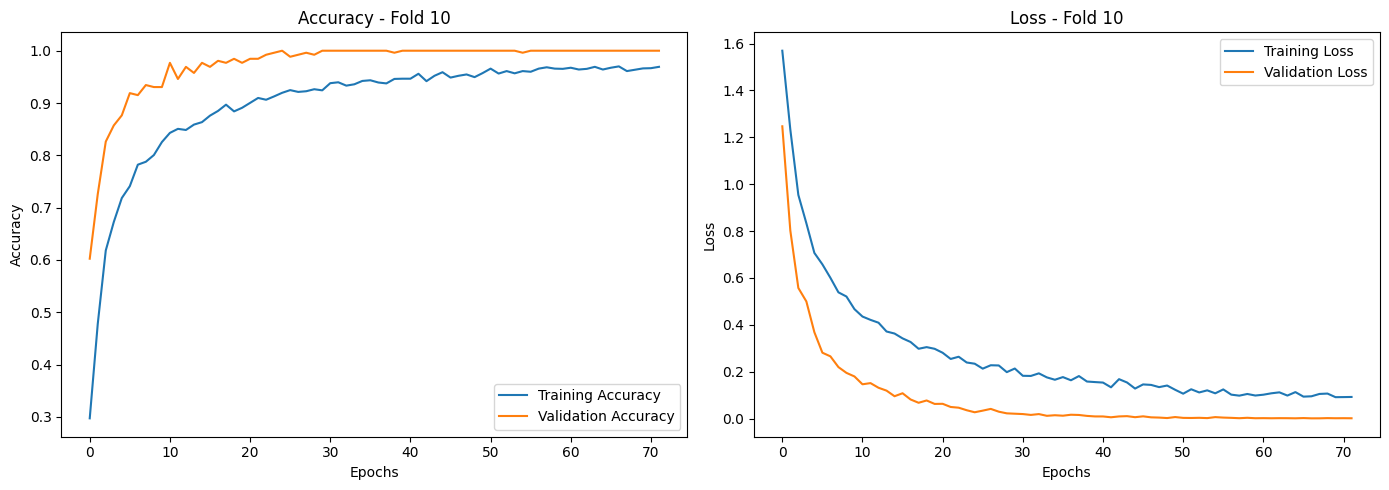

9/9 [==============================] - 0s 2ms/step


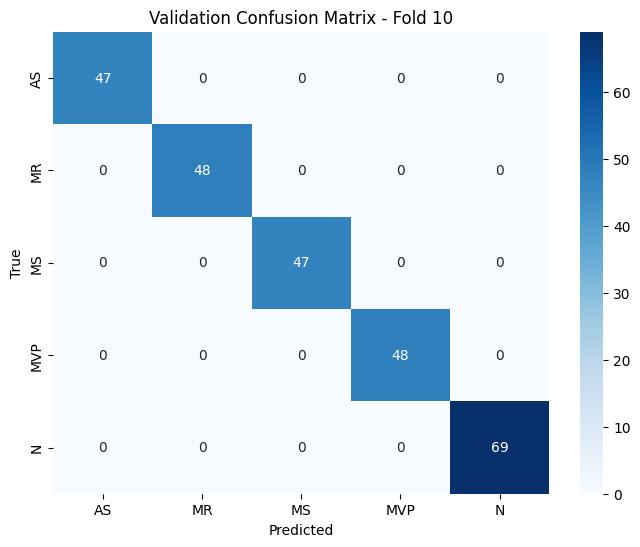

8/8 [==============================] - 0s 2ms/step


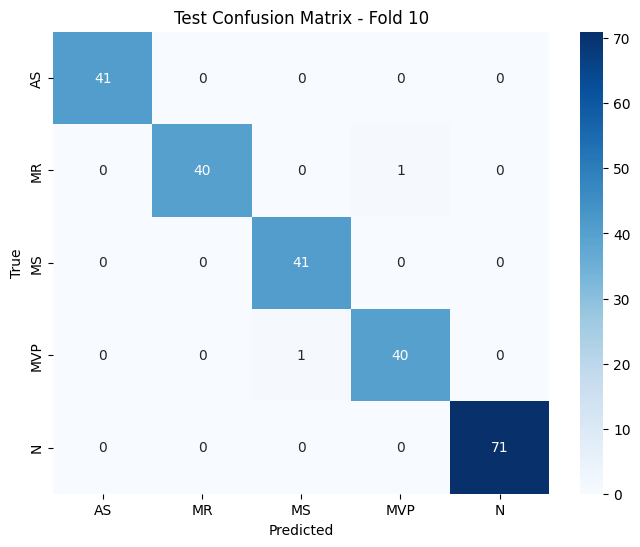


Fold 10 Results:
  Train Acc: 0.9692
  Val Acc:   1.0000
  Test Acc:  0.9915
  Sensitivity (macro): 0.9902
  Specificity (macro): 0.9979
  F1 Score (macro):    0.9902
  Saved model_fold_10.h5


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [18]:
# Prepare cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialize results
train_acc_results = []
val_acc_results = []
test_acc_results = []
sensitivity_results = []
specificity_results = []
f1_score_results = []

best_test_acc = 0
best_model = None

# Loop over each fold
for fold, (train_index, val_index) in enumerate(kf.split(train_data_mfccs, encoded_train_labels)):
    print(f'\n{"="*60}')
    print(f'FOLD {fold+1}/5')
    print(f'{"="*60}')

    X_train, X_val = train_data_mfccs[train_index], train_data_mfccs[val_index]
    y_train, y_val = train_labels_cat[train_index], train_labels_cat[val_index]

    # Build model (using tf_keras for Keras 2 compatibility)
    model = Sequential()
    input_shape = X_train.shape[1:]
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile (use tf_keras optimizer)
    learning_rate = 0.00001
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train with class weights
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=8,
        epochs=1000,
        callbacks=[early_stopping],
        class_weight=class_weights,
        verbose=1
    )

    # --- Training & Validation Accuracy ---
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    train_acc_results.append(final_train_acc)
    val_acc_results.append(final_val_acc)

    # --- Plot Training Curves ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'Accuracy - Fold {fold+1}')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].set_title(f'Loss - Fold {fold+1}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Validation Confusion Matrix ---
    y_val_pred = model.predict(X_val)
    y_val_pred_classes = np.argmax(y_val_pred, axis=1)
    y_val_true_classes = np.argmax(y_val, axis=1)

    plt.figure(figsize=(8, 6))
    cm_val = confusion_matrix(y_val_true_classes, y_val_pred_classes)
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Validation Confusion Matrix - Fold {fold+1}')
    plt.show()

    # --- Test Set Evaluation ---
    y_test_pred = model.predict(test_data_mfccs)
    y_test_pred_classes = np.argmax(y_test_pred, axis=1)
    y_test_true_classes = np.argmax(test_labels_cat, axis=1)

    test_acc = accuracy_score(y_test_true_classes, y_test_pred_classes)
    test_sens = recall_score(y_test_true_classes, y_test_pred_classes, average='macro')
    test_spec = specificity(y_test_true_classes, y_test_pred_classes)
    test_f1 = f1_score(y_test_true_classes, y_test_pred_classes, average='macro')

    test_acc_results.append(test_acc)
    sensitivity_results.append(test_sens)
    specificity_results.append(test_spec)
    f1_score_results.append(test_f1)

    # Test Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm_test = confusion_matrix(y_test_true_classes, y_test_pred_classes)
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Test Confusion Matrix - Fold {fold+1}')
    plt.show()

    print(f'\nFold {fold+1} Results:')
    print(f'  Train Acc: {final_train_acc:.4f}')
    print(f'  Val Acc:   {final_val_acc:.4f}')
    print(f'  Test Acc:  {test_acc:.4f}')
    print(f'  Sensitivity (macro): {test_sens:.4f}')
    print(f'  Specificity (macro): {test_spec:.4f}')
    print(f'  F1 Score (macro):    {test_f1:.4f}')

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model = model
        best_fold = fold + 1
        print(f'  >>> New best model! (Fold {fold+1}, Test Acc: {test_acc:.4f})')

    # Save each fold model
    model.save(f'model_fold_{fold+1}.h5')
    print(f'  Saved model_fold_{fold+1}.h5')

## Step 6: Overall Results Summary

In [19]:
print('=' * 60)
print('OVERALL RESULTS (5-Fold Cross-Validation)')
print('=' * 60)
print(f'\nTraining Accuracy:  {np.mean(train_acc_results):.4f} +/- {np.std(train_acc_results):.4f}')
print(f'Validation Accuracy: {np.mean(val_acc_results):.4f} +/- {np.std(val_acc_results):.4f}')
print(f'Test Accuracy:       {np.mean(test_acc_results):.4f} +/- {np.std(test_acc_results):.4f}')
print(f'Sensitivity (macro): {np.mean(sensitivity_results):.4f} +/- {np.std(sensitivity_results):.4f}')
print(f'Specificity (macro): {np.mean(specificity_results):.4f} +/- {np.std(specificity_results):.4f}')
print(f'F1 Score (macro):    {np.mean(f1_score_results):.4f} +/- {np.std(f1_score_results):.4f}')
print(f'\nBest model: Fold {best_fold} (Test Acc: {best_test_acc:.4f})')

# Per-fold table
print(f'\n{"Fold":>5s} | {"Train":>8s} | {"Val":>8s} | {"Test":>8s} | {"Sens":>8s} | {"Spec":>8s} | {"F1":>8s}')
print('-' * 65)
for i in range(5):
    print(f'{i+1:5d} | {train_acc_results[i]:8.4f} | {val_acc_results[i]:8.4f} | {test_acc_results[i]:8.4f} | {sensitivity_results[i]:8.4f} | {specificity_results[i]:8.4f} | {f1_score_results[i]:8.4f}')

OVERALL RESULTS (5-Fold Cross-Validation)

Training Accuracy:  0.9589 +/- 0.0113
Validation Accuracy: 0.9992 +/- 0.0015
Test Accuracy:       0.9923 +/- 0.0032
Sensitivity (macro): 0.9912 +/- 0.0037
Specificity (macro): 0.9981 +/- 0.0008
F1 Score (macro):    0.9912 +/- 0.0036

Best model: Fold 4 (Test Acc: 0.9957)

 Fold |    Train |      Val |     Test |     Sens |     Spec |       F1
-----------------------------------------------------------------
    1 |   0.9516 |   1.0000 |   0.9872 |   0.9854 |   0.9969 |   0.9854
    2 |   0.9752 |   1.0000 |   0.9915 |   0.9902 |   0.9979 |   0.9902
    3 |   0.9413 |   1.0000 |   0.9915 |   0.9902 |   0.9979 |   0.9902
    4 |   0.9683 |   1.0000 |   0.9957 |   0.9951 |   0.9990 |   0.9951
    5 |   0.9486 |   1.0000 |   0.9957 |   0.9951 |   0.9990 |   0.9951


## Step 7: Save Best Model

In [20]:
# Save the best model to Google Drive
save_path = os.path.join(DRIVE_BASE, f'best_model_fold_{best_fold}.h5')
best_model.save(save_path)
print(f'Best model saved to: {save_path}')

# Also save locally in Colab
best_model.save(f'best_model_fold_{best_fold}.h5')
print(f'Also saved locally: best_model_fold_{best_fold}.h5')

# Print class label mapping for reference
print(f'\nClass label mapping (for prediction notebook):')
print(f'CLASS_LABELS = {class_names}')
print(f'(Alphabetical order, matching LabelEncoder)')

Best model saved to: /content/drive/MyDrive/NPU Project/DeepSignal/best_model_fold_4.h5
Also saved locally: best_model_fold_4.h5

Class label mapping (for prediction notebook):
CLASS_LABELS = [np.str_('AS'), np.str_('MR'), np.str_('MS'), np.str_('MVP'), np.str_('N')]
(Alphabetical order, matching LabelEncoder)


## Step 8: Final Test Confusion Matrix (Best Model)

8/8 [==============================] - 0s 2ms/step
Per-class Test Accuracy (Best Model):
  AS: 41/41 = 100.0%
  MR: 40/41 = 97.6%
  MS: 41/41 = 100.0%
  MVP: 41/41 = 100.0%
  N: 71/71 = 100.0%


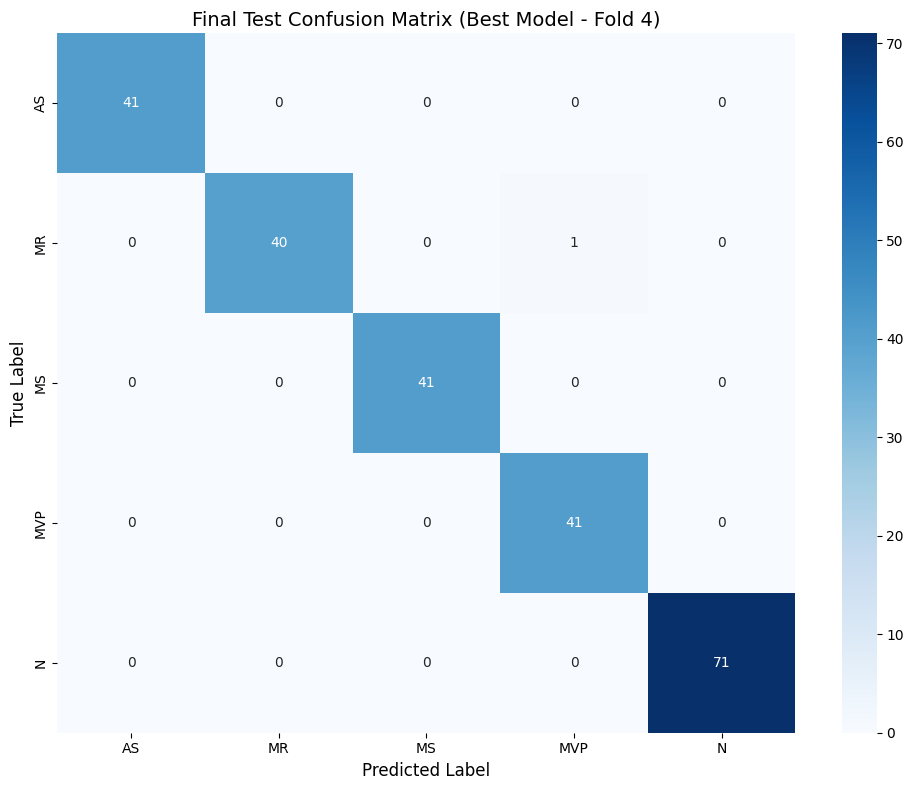


Overall Test Accuracy: 0.9957
Macro F1 Score: 0.9951


In [21]:
# Final detailed evaluation of the best model
y_test_pred = best_model.predict(test_data_mfccs)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true_classes = np.argmax(test_labels_cat, axis=1)

# Per-class accuracy
print('Per-class Test Accuracy (Best Model):')
cm = confusion_matrix(y_test_true_classes, y_test_pred_classes)
for i, name in enumerate(class_names):
    class_total = cm[i].sum()
    class_correct = cm[i][i]
    print(f'  {name}: {class_correct}/{class_total} = {class_correct/class_total*100:.1f}%')

# Final confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Final Test Confusion Matrix (Best Model - Fold {best_fold})', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nOverall Test Accuracy: {accuracy_score(y_test_true_classes, y_test_pred_classes):.4f}')
print(f'Macro F1 Score: {f1_score(y_test_true_classes, y_test_pred_classes, average="macro"):.4f}')